# Partial Derivatives - Part 2

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Partial derivatives - Part 2"* (Week 2 — Gradients and Gradient Descent).

This short lecture works through **one more example** to nail down the technique:

$$
f(x,y) = 3x^2 y^3
$$

and computes both partial derivatives step by step using the **two-step recipe** and the
"**box the constant**" trick.

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Partial Derivatives - Part 1*.

## 1. Recap: the two-step recipe

From Part 1, computing a partial derivative is always the same two steps:

1. **Treat all other variables as constants.**
2. **Differentiate using the normal rules of differentiation.**

A handy visual aid from the lecture: **draw a box around** every factor that is a
constant, so you don't accidentally differentiate it. Constants come along for the ride
via the scalar-multiple rule

$$
\frac{d}{dx}\big[c \cdot u(x)\big] = c \cdot u'(x).
$$

## 2. The worked example: $f(x,y) = 3x^2 y^3$

### Partial derivative with respect to $x$

We are differentiating with respect to $x$, so **$y$ is a constant** — box $y^3$:

$$
f(x,y) = 3 \cdot x^2 \cdot \boxed{y^3}
$$

Apply the rules:

- the leading $3$ is a constant scalar → stays out front,
- $\dfrac{d}{dx}x^2 = 2x$,
- $\boxed{y^3}$ is a constant → multiplies through unchanged.

$$
\frac{\partial f}{\partial x} = 3 \cdot 2x \cdot y^3 = \boxed{6xy^3}
$$

### Partial derivative with respect to $y$

Now we differentiate with respect to $y$, so **$x$ is a constant** — box $x^2$:

$$
f(x,y) = 3 \cdot \boxed{x^2} \cdot y^3
$$

- the $3$ stays out front,
- $\boxed{x^2}$ is a constant → multiplies through,
- $\dfrac{d}{dy}y^3 = 3y^2$.

$$
\frac{\partial f}{\partial y} = 3 \cdot x^2 \cdot 3y^2 = \boxed{9x^2 y^2}
$$

## 3. Symbolic check with SymPy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x, y = sp.symbols('x y')
f_sym = 3 * x**2 * y**3

fx = sp.diff(f_sym, x)
fy = sp.diff(f_sym, y)

print("f(x, y)      =", f_sym)
print("∂f/∂x  (f_x) =", fx)     # 6*x*y**3
print("∂f/∂y  (f_y) =", fy)     # 9*x**2*y**2

f(x, y)      = 3*x**2*y**3
∂f/∂x  (f_x) = 6*x*y**3
∂f/∂y  (f_y) = 9*x**2*y**2


## 4. Numerical check

A partial derivative is an ordinary 1D derivative along one axis. We confirm both
expressions with a central finite difference at a few points.

In [2]:
def f(x, y):
    return 3 * x**2 * y**3

def fx_exact(x, y):
    return 6 * x * y**3

def fy_exact(x, y):
    return 9 * x**2 * y**2

def partial_x(f, x, y, h=1e-6):
    return (f(x + h, y) - f(x - h, y)) / (2 * h)

def partial_y(f, x, y, h=1e-6):
    return (f(x, y + h) - f(x, y - h)) / (2 * h)

for (x0, y0) in [(1.0, 1.0), (2.0, -1.0), (0.5, 2.0)]:
    print(f"At ({x0:>4}, {y0:>4}): "
          f"f_x num={partial_x(f, x0, y0):9.4f} (exact {fx_exact(x0, y0):9.4f}) | "
          f"f_y num={partial_y(f, x0, y0):9.4f} (exact {fy_exact(x0, y0):9.4f})")

At ( 1.0,  1.0): f_x num=   6.0000 (exact    6.0000) | f_y num=   9.0000 (exact    9.0000)
At ( 2.0, -1.0): f_x num= -12.0000 (exact  -12.0000) | f_y num=  36.0000 (exact   36.0000)
At ( 0.5,  2.0): f_x num=  24.0000 (exact   24.0000) | f_y num=   9.0000 (exact    9.0000)


## 5. Visualizing the surface and its slices

The surface $z = 3x^2y^3$ and the two slices through the point $(1, 1)$, where
$f=3$, $f_x = 6$ and $f_y = 9$.

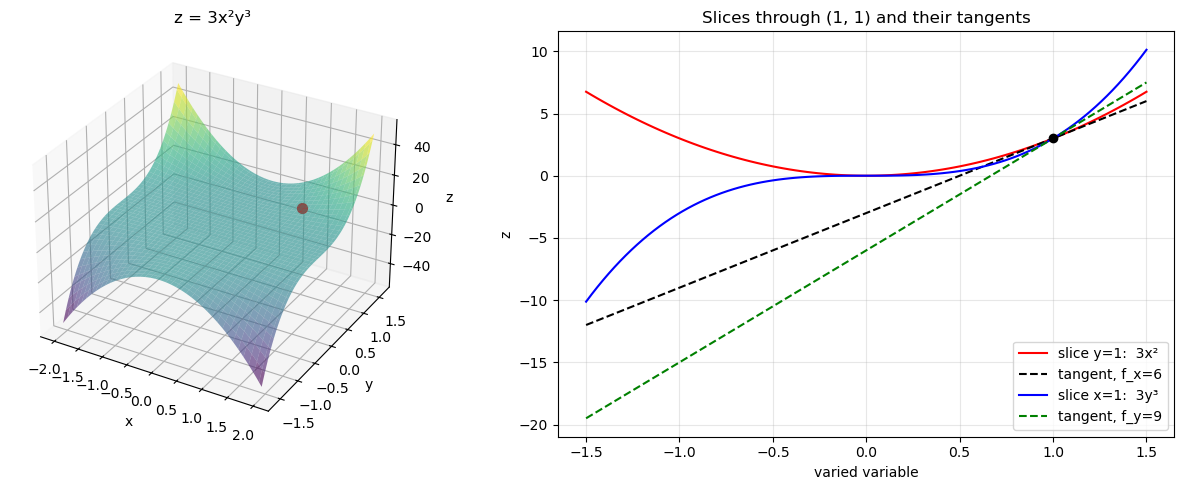

In [3]:
x0, y0 = 1.0, 1.0
f0  = 3 * x0**2 * y0**3
sx  = 6 * x0 * y0**3      # f_x at (1,1) = 6
sy  = 9 * x0**2 * y0**2   # f_y at (1,1) = 9

gx = np.linspace(-2, 2, 80)
gy = np.linspace(-1.6, 1.6, 80)
X, Y = np.meshgrid(gx, gy)
Z = 3 * X**2 * Y**3

t = np.linspace(-1.5, 1.5, 100)

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.6)
ax.scatter([x0], [y0], [f0], color="red", s=50)
ax.set_title("z = 3x²y³"); ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, 3*t**2*y0**3, "r", label="slice y=1:  3x²")
ax2.plot(t, f0 + sx*(t - x0), "k--", label=f"tangent, f_x={sx:.0f}")
ax2.plot(t, 3*x0**2*t**3, "b", label="slice x=1:  3y³")
ax2.plot(t, f0 + sy*(t - y0), "g--", label=f"tangent, f_y={sy:.0f}")
ax2.plot(x0, f0, "ko")
ax2.set_title("Slices through (1, 1) and their tangents")
ax2.set_xlabel("varied variable"); ax2.set_ylabel("z")
ax2.grid(True, alpha=0.3); ax2.legend()

plt.tight_layout()
plt.show()

## 6. More practice (worked with SymPy)

The same recipe handles any polynomial / mixed term. Box the constants, differentiate the
rest.

In [4]:
x, y = sp.symbols('x y')

examples = [
    5 * x**3 * y**2,
    x**2 * y + x * y**2,
    sp.sin(x) * y**2,
]

for expr in examples:
    print("f      =", expr)
    print("  f_x  =", sp.diff(expr, x))
    print("  f_y  =", sp.diff(expr, y))
    print("-" * 50)

f      = 5*x**3*y**2
  f_x  = 15*x**2*y**2
  f_y  = 10*x**3*y
--------------------------------------------------
f      = x**2*y + x*y**2
  f_x  = 2*x*y + y**2
  f_y  = x**2 + 2*x*y
--------------------------------------------------
f      = y**2*sin(x)
  f_x  = y**2*cos(x)
  f_y  = 2*y*sin(x)
--------------------------------------------------


## 7. Exercises

### Basic
1. For $f(x,y) = 3x^2 y^3$, state $f_x$ and $f_y$ from memory.
2. Which factor do you "box" (treat as a constant) when computing $f_y$?

### Intermediate
3. Compute $f_x$ and $f_y$ for $f(x,y) = 4x^3 y^2$.
4. Compute $f_x$ and $f_y$ for $f(x,y) = x^2 y^3 + 2xy$.

### Advanced
5. Compute all partial derivatives of $g(x,y,z) = x^2 y^3 z$.
6. For $f(x,y)=3x^2y^3$, evaluate $f_x$ and $f_y$ at $(2, -1)$ and confirm the signs make
   sense from the formulas.

## 8. Solutions / Checks

In [5]:
x, y, z = sp.symbols('x y z')

f = 3*x**2*y**3
print("1. f_x =", sp.diff(f, x), ", f_y =", sp.diff(f, y))
print("2. box x² (treat x as constant) when computing f_y")

f3 = 4*x**3*y**2
print("3. f_x =", sp.diff(f3, x), ", f_y =", sp.diff(f3, y))

f4 = x**2*y**3 + 2*x*y
print("4. f_x =", sp.diff(f4, x), ", f_y =", sp.diff(f4, y))

g = x**2*y**3*z
print("5. g_x =", sp.diff(g, x), ", g_y =", sp.diff(g, y), ", g_z =", sp.diff(g, z))

print("6. at (2,-1): f_x =", sp.diff(f, x).subs({x:2, y:-1}),
      ", f_y =", sp.diff(f, y).subs({x:2, y:-1}))

1. f_x = 6*x*y**3 , f_y = 9*x**2*y**2
2. box x² (treat x as constant) when computing f_y
3. f_x = 12*x**2*y**2 , f_y = 8*x**3*y
4. f_x = 2*x*y**3 + 2*y , f_y = 3*x**2*y**2 + 2*x
5. g_x = 2*x*y**3*z , g_y = 3*x**2*y**2*z , g_z = x**2*y**3
6. at (2,-1): f_x = -12 , f_y = 36


## 9. Conclusion

- The **two-step recipe** handles every case: box the constants, then differentiate.
- For $f(x,y) = 3x^2y^3$:

$$
\frac{\partial f}{\partial x} = 6xy^3, \qquad \frac{\partial f}{\partial y} = 9x^2y^2 .
$$

- The **scalar-multiple rule** lets constant factors (including the "boxed" variables)
  pass straight through the derivative.

Next, these partial derivatives are collected into the **gradient**
$\nabla f = (f_x, f_y)$ — the topic of the following lecture.

## Appendix — Source transcript

Transcribed from the Coursera interactive transcript of
*"Partial derivatives - Part 2"*
(*Calculus for Machine Learning and Data Science*, Week 2), read via the
Claude-for-Chrome browser extension. Key spoken points, lightly cleaned:

> One more example: $f(x,y)=3x^2y^3$. To find $\partial f/\partial x$, treat $y$ as a
> constant — box $y^3$. The $3$ is a constant scalar that stays out front, the derivative
> of $x^2$ is $2x$, and the boxed $y^3$ multiplies through, giving $3\cdot 2x\cdot y^3 =
> 6xy^3$. For $\partial f/\partial y$, treat $x$ as the constant — box $x^2$; the
> derivative of $y^3$ is $3y^2$, giving $3\cdot x^2\cdot 3y^2 = 9x^2y^2$.